# 2 · Sound Classification on top classes

KNN classification on the BSD10k **subset** created in notebook 1.
Compares MFCC, FSD-SINet, and CLAP embeddings, then digs into misclassifications by listening.
Finally, it uses the Freesound API to download some sounds and look at the classification over those.

This notebook works on classification over the top classes only. The third notebook (code is failry similar to this one) works on classifiers over the whole vocabulary classes.

## 0 · Setup

In [1]:
import os, sys, json, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, IFrame

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedShuffleSplit

# ── Paths (same root as notebook 1) ──────────────────────────────────────────
METADATA_FOLDER  = '../metadata'
EMBEDDINGS_FOLDER = '../embeddings'
SUBSET_CSV       = '../metadata/subset_metadata.csv'
# ─────────────────────────────────────────────────────────────────────────────

def show_sound_player(sound_id):
    display(IFrame(f'https://freesound.org/embed/sound/iframe/{sound_id}/simple/medium/', width=596, height=100))


## 1 · Load subset metadata

In [2]:
subset_df = pd.read_csv(SUBSET_CSV)
print(f'Loaded {len(subset_df)} sounds, {subset_df["class"].nunique()} classes')
display(subset_df.groupby(['class', 'class_name']).size().rename('count'))


Loaded 7205 sounds, 15 classes


class  class_name        
fx-a   Sound effects          168
fx-n   Sound effects          659
fx-o   Sound effects         1203
fx-v   Sound effects          199
is-k   Instrument samples     111
is-s   Instrument samples     529
is-w   Instrument samples     552
m-m    Music                  291
m-si   Music                  655
m-sp   Music                  689
sp-c   Speech                  96
sp-s   Speech                 801
ss-i   Soundscapes            178
ss-n   Soundscapes            389
ss-u   Soundscapes            685
Name: count, dtype: int64

## 2 · Train / test split

BSD10k (v1.0) does not ship with a predefined split column.
We create a **stratified 80/20 split** so every class is proportionally represented in both sets.
The split is fixed with `random_state=42` for reproducibility.


In [3]:
train_idx = subset_df.index[subset_df['set'] == 'train'].tolist()
test_idx = subset_df.index[subset_df['set'] == 'test'].tolist()

train_df = subset_df.iloc[train_idx].copy()
test_df  = subset_df.iloc[test_idx].copy()

print(f'Train: {len(train_df)} sounds   Test: {len(test_df)} sounds')
print()
split_summary = pd.DataFrame({
    'train': train_df['class_name'].value_counts(),
    'test':  test_df['class_name'].value_counts(),
}).fillna(0).astype(int)
display(split_summary)


Train: 6605 sounds   Test: 600 sounds



,train,test
class_name,,
Sound effects,2069,160
Music,1515,120
Soundscapes,1132,120
Instrument samples,1072,120
Speech,817,80


## 3 · Load embeddings

In [4]:
def load_embeddings(df, method, embeddings_folder):
    """Load pre-computed .npy embeddings for every sound in df."""
    folder = os.path.join(embeddings_folder, method)
    paths  = [os.path.join(folder, f'{sid}.npy') for sid in df['sound_id']]

    # Skip sounds whose embedding file is missing (e.g. extraction errors)
    valid_mask = np.array([os.path.exists(p) for p in paths])
    if valid_mask.sum() < len(df):
        print(f'  [{method}] {(~valid_mask).sum()} files missing — skipping those sounds')

    example = np.load(paths[valid_mask.argmax()])
    X = np.zeros((len(paths), len(example)))
    for i, (p, ok) in enumerate(zip(paths, valid_mask)):
        if ok:
            X[i] = np.load(p)
    return X, valid_mask


EMBEDDING_TYPES = [d for d in ['mfcc', 'fsdsinet', 'clap', 'fs_similarity']
                   if os.path.isdir(os.path.join(EMBEDDINGS_FOLDER, d))]
print(f'Available embedding types: {EMBEDDING_TYPES}')

X_train_all, X_test_all = {}, {}
for method in EMBEDDING_TYPES:
    X_tr, mask_tr = load_embeddings(train_df, method, EMBEDDINGS_FOLDER)
    X_te, mask_te = load_embeddings(test_df,  method, EMBEDDINGS_FOLDER)
    X_train_all[method] = X_tr
    X_test_all[method]  = X_te
    print(f'  {method}: train {X_tr.shape}  test {X_te.shape}')

y_train = train_df['class_name'].values
y_test  = test_df['class_name'].values


Available embedding types: ['mfcc', 'fsdsinet', 'clap', 'fs_similarity']
  mfcc: train (6605, 13)  test (600, 13)
  fsdsinet: train (6605, 512)  test (600, 512)
  clap: train (6605, 512)  test (600, 512)
  fs_similarity: train (6605, 100)  test (600, 100)


## 4 · Compare embedding types (KNN, k=5)

In [5]:
results = {}
print(f'{'Embedding':<15}  {'Accuracy':>10}  {'Random baseline':>16}')
print('-' * 45)

for method in EMBEDDING_TYPES:
    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_train_all[method])
    X_te    = scaler.transform(X_test_all[method])

    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    acc      = accuracy_score(y_test, y_pred)
    baseline = 1.0 / len(set(y_train))
    results[method] = dict(acc=acc, baseline=baseline, y_pred=y_pred, clf=clf, scaler=scaler)

    print(f'{method:<15}  {acc:>10.3f}  {baseline:>16.3f}')


Embedding          Accuracy   Random baseline
---------------------------------------------
mfcc                  0.528             0.200
fsdsinet              0.777             0.200
clap                  0.885             0.200
fs_similarity         0.707             0.200


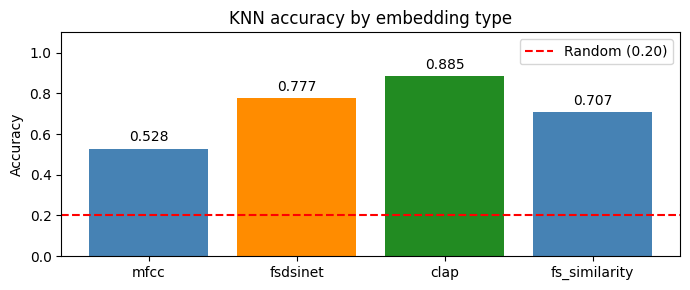

In [6]:
# Bar chart comparison
methods = list(results.keys())
accs    = [results[m]['acc'] for m in methods]
baseline = results[methods[0]]['baseline']

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(methods, accs, color=['steelblue', 'darkorange', 'forestgreen'][:len(methods)])
ax.axhline(baseline, color='red', linestyle='--', label=f'Random ({baseline:.2f})')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('KNN accuracy by embedding type')
ax.legend()
plt.tight_layout()
plt.show()


## 5 · Deep dive: best embedding and confusion matrices

Classification report for the best performing embedding and confusion matrices.


In [7]:
best = max(results, key=lambda m: results[m]['acc'])
print(f'Best embedding: {best}  (accuracy = {results[best]["acc"]:.3f})')
print()
print(classification_report(y_test, results[best]['y_pred']))


Best embedding: clap  (accuracy = 0.885)

                    precision    recall  f1-score   support

Instrument samples       0.99      0.96      0.97       120
             Music       0.96      0.97      0.96       120
     Sound effects       0.94      0.82      0.88       160
       Soundscapes       0.68      0.92      0.78       120
            Speech       0.95      0.72      0.82        80

          accuracy                           0.89       600
         macro avg       0.90      0.88      0.88       600
      weighted avg       0.90      0.89      0.89       600



Confusion Matrices across all embeddings:


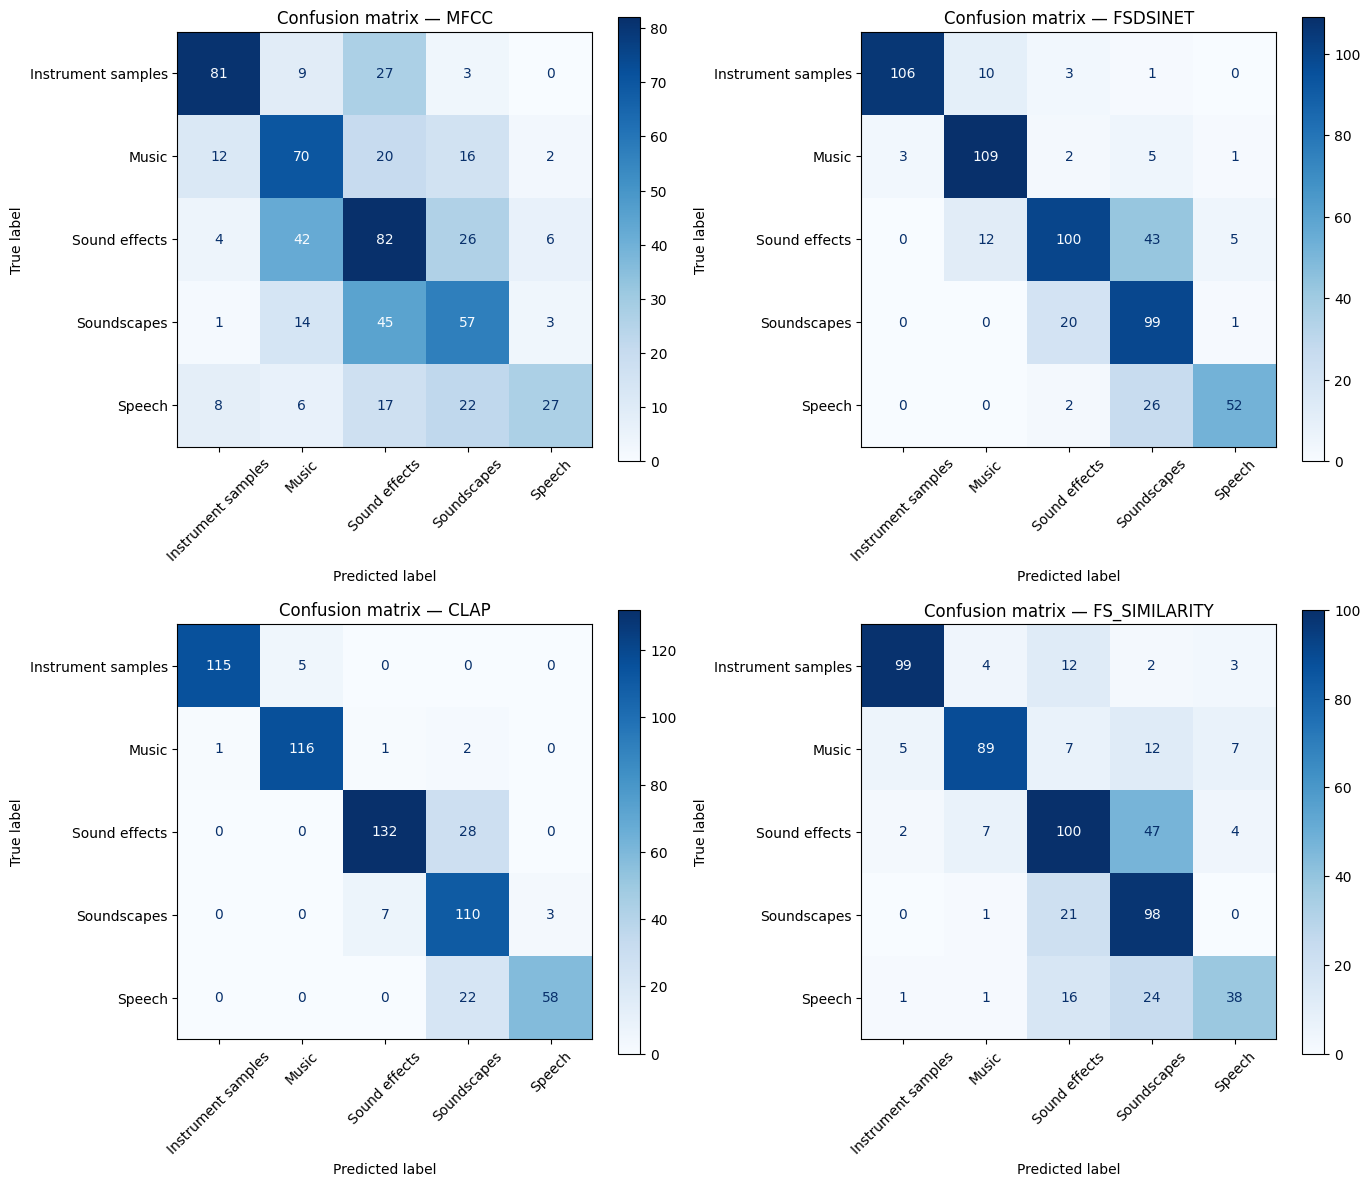

In [8]:
import math

# Determine grid size based on the number of embeddings
num_embeddings = len(EMBEDDING_TYPES)
cols = 2
rows = math.ceil(num_embeddings / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
axes = axes.flatten()

print("Confusion Matrices across all embeddings:")

for i, method in enumerate(EMBEDDING_TYPES):
    clf = results[method]['clf']
    y_pred = results[method]['y_pred']
    
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
    
    disp.plot(ax=axes[i], xticks_rotation=45, cmap='Blues')
    axes[i].set_title(f'Confusion matrix — {method.upper()}')

# Hide any empty subplots if we have an odd number of embeddings
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6 · Per-class F1 across all embeddings

,mfcc,fsdsinet,clap,fs_similarity
Instrument samples,0.717,0.926,0.975,0.872
Music,0.536,0.869,0.963,0.802
Sound effects,0.467,0.697,0.880,0.633
Soundscapes,0.467,0.673,0.780,0.647
Speech,0.458,0.748,0.823,0.576


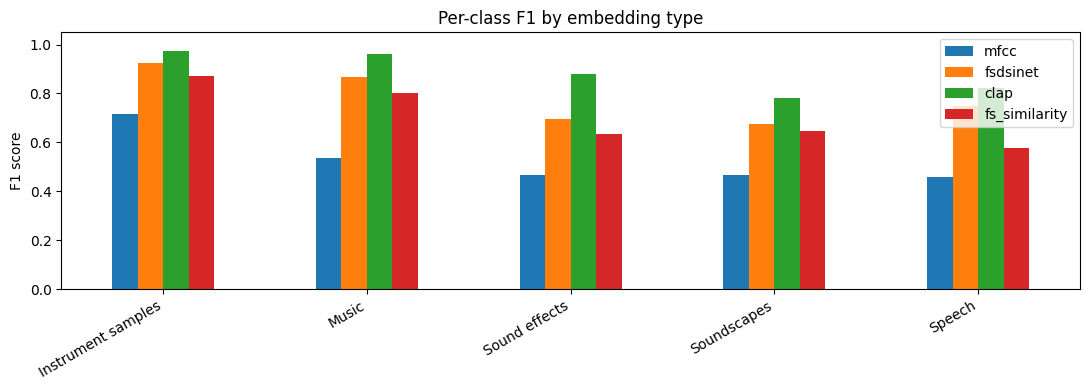

In [9]:
from sklearn.metrics import classification_report

classes = sorted(set(y_test))
f1_data = {}
for method in EMBEDDING_TYPES:
    report = classification_report(y_test, results[method]['y_pred'], output_dict=True)
    f1_data[method] = {cls: report.get(cls, {}).get('f1-score', 0.0) for cls in classes}

f1_df = pd.DataFrame(f1_data, index=classes)
display(f1_df.round(3))

f1_df.plot(kind='bar', figsize=(11, 4), ylim=(0, 1.05))
plt.ylabel('F1 score')
plt.title('Per-class F1 by embedding type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 7 · Misclassification analysis

Listen to wrongly classified sounds and reason about *why* the model was confused.
Focus on:
- Is the ground-truth label arguably correct for this specific sound, or is it borderline?
- Does the acoustic content sound more like the predicted class?
- Does a different embedding type get it right?


In [10]:
from collections import Counter

y_pred_best = results[best]['y_pred']
misclassified = [
    {'sound_id': test_df.iloc[i]['sound_id'],
     'title':    test_df.iloc[i]['title'],
     'gt':       y_test[i],
     'pred':     y_pred_best[i]}
    for i in np.where(y_test != y_pred_best)[0]
]

print(f'Total misclassifications: {len(misclassified)} / {len(y_test)}')
print()
pairs = Counter((m['gt'], m['pred']) for m in misclassified)
print(f'{'Ground truth':<30}  {'Predicted':<30}  {'Count':>5}')
print('-' * 70)
for (gt, pred), count in pairs.most_common(15):
    print(f'{gt:<30}  {pred:<30}  {count:>5}')


Total misclassifications: 69 / 600

Ground truth                    Predicted                       Count
----------------------------------------------------------------------
Sound effects                   Soundscapes                        28
Speech                          Soundscapes                        22
Soundscapes                     Sound effects                       7
Instrument samples              Music                               5
Soundscapes                     Speech                              3
Music                           Soundscapes                         2
Music                           Instrument samples                  1
Music                           Sound effects                       1


In [11]:
# Listen to 5 random misclassifications
for m in random.sample(misclassified, min(5, len(misclassified))):
    print('─' * 60)
    print(f"Title:        {m['title']}")
    print(f"Ground truth: {m['gt']}")
    print(f"Predicted:    {m['pred']}")
    show_sound_player(m['sound_id'])


────────────────────────────────────────────────────────────
Title:        Black Casqued Hornbill 5.wav
Ground truth: Sound effects
Predicted:    Soundscapes


────────────────────────────────────────────────────────────
Title:        20110503_clucking.05.wav
Ground truth: Sound effects
Predicted:    Soundscapes


────────────────────────────────────────────────────────────
Title:        00916 children scream 1.wav
Ground truth: Speech
Predicted:    Soundscapes


────────────────────────────────────────────────────────────
Title:        you want us to get loud.wav
Ground truth: Speech
Predicted:    Soundscapes


────────────────────────────────────────────────────────────
Title:        metro-tiananmen.wav
Ground truth: Soundscapes
Predicted:    Speech
